Customer Churn Prediction using classical ML models.

Goal: predict churn probability using tabular data.

Metric: ROC-AUC.


## 1. Setup & Configuration {#setup}

In [59]:
"""Import required libraries and configure environment."""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

print(f'Random seed: {RANDOM_STATE}')

Random seed: 42


## 2. Data Loading {#loading}

In [60]:
"""Load training, test, and submission reference datasets."""

train = pd.read_csv('../datasets/train.csv')
test = pd.read_csv('../datasets/test.csv')
submission = pd.read_csv('../datasets/submission.csv')

print('Dataset Shapes:')
print(f'  Training:    {train.shape}')
print(f'  Test:        {test.shape}')
print(f'  Submission:  {submission.shape}')

print('\nFirst few rows of training data:')
print(train.head())

Dataset Shapes:
  Training:    (5282, 20)
  Test:        (1761, 19)
  Submission:  (1761, 2)

First few rows of training data:
   ClientPeriod  MonthlySpending TotalSpent     Sex  IsSeniorCitizen  \
0            55            19.50    1026.35    Male                0   
1            72            25.85     1872.2    Male                0   
2             1            75.90       75.9    Male                0   
3            32            79.30       2570  Female                1   
4            60           115.25    6758.45  Female                0   

  HasPartner HasChild HasPhoneService HasMultiplePhoneNumbers  \
0        Yes      Yes             Yes                      No   
1        Yes       No             Yes                     Yes   
2         No       No             Yes                      No   
3        Yes       No             Yes                     Yes   
4        Yes      Yes             Yes                     Yes   

  HasInternetService HasOnlineSecurityService    

## 3. Exploratory Data Analysis {#eda}

### 3.1 Data Overview

In [61]:
"""Inspect data types, missing values, and basic statistics."""

print('='*70)
print('TRAINING DATA INFO')
print('='*70)
print(train.info())

print('\nMissing Values:')
missing_count = train.isnull().sum().sum()
print(f'  Total: {missing_count} missing values')
if missing_count == 0:
    print('  ✓ No missing values - data is clean!')

print('\n' + '='*70)
print('TEST DATA INFO')
print('='*70)
print(test.info())

print('\nMissing Values:')
missing_count_test = test.isnull().sum().sum()
print(f'  Total: {missing_count_test} missing values')
if missing_count_test == 0:
    print('  ✓ No missing values - data is clean!')

TRAINING DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   ob

### 3.2 Feature Classification

In [62]:
"""Identify numerical and categorical features."""

numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

# Remove target and Id from feature lists
if 'Churn' in numerical_features:
    numerical_features.remove('Churn')
if 'Id' in numerical_features:
    numerical_features.remove('Id')
if 'Id' in categorical_features:
    categorical_features.remove('Id')

print(f'Numerical Features ({len(numerical_features)}): {numerical_features}')
print(f'\nCategorical Features ({len(categorical_features)}): {categorical_features}')
print(f'\nTarget Variable: Churn')

Numerical Features (3): ['ClientPeriod', 'MonthlySpending', 'IsSeniorCitizen']

Categorical Features (16): ['TotalSpent', 'Sex', 'HasPartner', 'HasChild', 'HasPhoneService', 'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'IsBillingPaperless', 'PaymentMethod']

Target Variable: Churn


### 3.3 Target Variable Analysis

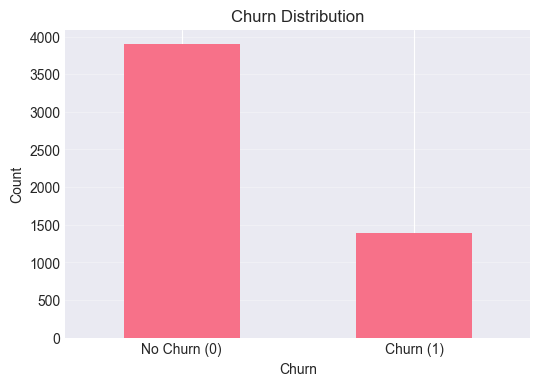

Dataset is imbalanced


In [63]:
"""Analyze the distribution of the target variable."""

churn_counts = train['Churn'].value_counts()

# Bar plot
plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar')

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn (0)', 'Churn (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

print('Dataset is imbalanced')


### 3.4 Numerical Features Analysis

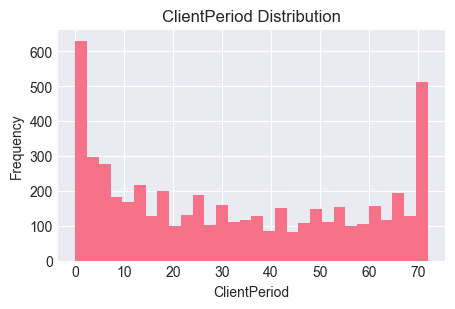

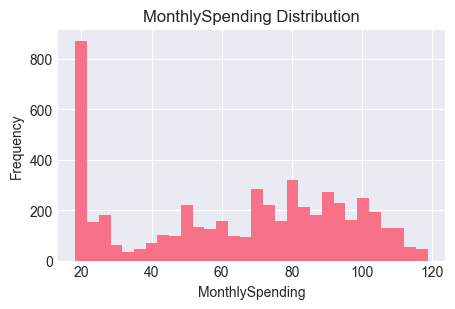

In [64]:
"""Analyze distributions of numerical features."""

for feature in numerical_features[:2]:
    plt.figure(figsize=(5, 3))
    plt.hist(train[feature], bins=30)
    plt.title(f'{feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

## 4. Data Preprocessing {#preprocessing}

### 4.1 Prepare Features and Target

In [65]:
"""Separate features from target variable and handle Id column."""

# Separate features and target
X_train = train.drop(['Churn'], axis=1)
y_train = train['Churn']
X_test = test.copy()

# Handle Id column
if 'Id' in X_train.columns:
    X_train = X_train.drop(['Id'], axis=1)

if 'Id' in X_test.columns:
    test_ids = X_test['Id'].copy()
    X_test = X_test.drop(['Id'], axis=1)
else:
    test_ids = pd.Series(range(len(X_test)), name='Id')

print('Data Separation Complete:')
print(f'  X_train shape: {X_train.shape}')
print(f'  y_train shape: {y_train.shape}')
print(f'  X_test shape:  {X_test.shape}')

Data Separation Complete:
  X_train shape: (5282, 19)
  y_train shape: (5282,)
  X_test shape:  (1761, 19)


### 4.2 Encode Categorical Features

In [66]:
"""Apply One-Hot Encoding to categorical features."""

print('Applying One-Hot Encoding...')
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=False)

print(f'After encoding:')
print(f'  X_train: {X_train_encoded.shape}')
print(f'  X_test:  {X_test_encoded.shape}')

# Align columns between train and test
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0

extra_cols = set(X_test_encoded.columns) - set(X_train_encoded.columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

X_test_encoded = X_test_encoded[X_train_encoded.columns]

print(f'\nAfter column alignment:')
print(f'  X_train: {X_train_encoded.shape}')
print(f'  X_test:  {X_test_encoded.shape}')
print('  ✓ Train and test have identical features')

Applying One-Hot Encoding...
After encoding:
  X_train: (5282, 5022)
  X_test:  (1761, 1754)

After column alignment:
  X_train: (5282, 5022)
  X_test:  (1761, 5022)
  ✓ Train and test have identical features


### 4.3 Normalize Numerical Features

In [67]:
"""Normalize numerical features using StandardScaler."""

scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Fit scaler on training data, transform both train and test
X_train_scaled[numerical_features] = scaler.fit_transform(X_train_encoded[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_encoded[numerical_features])

#print(f'\nScaled Features Summary (training data):')
#print(X_train_scaled[numerical_features].describe())


## 5. Model Development {#models}

We'll train and tune two different classifiers:
1. **Logistic Regression** - Linear model for baseline
2. **CatBoost** - Gradient boosting model for improved performance

### 5.1 Logistic Regression

In [68]:
"""Train Logistic Regression with hyperparameter tuning using GridSearchCV.

Hyperparameters:
  - C: Inverse of regularization strength (smaller = stronger regularization)
  - solver: Algorithm for optimization
  - max_iter: Maximum iterations for convergence
"""

print('='*70)
print('LOGISTIC REGRESSION - HYPERPARAMETER TUNING')
print('='*70)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500]
}

lr_model = LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1)

print('\nStarting GridSearchCV...')
print(f'Grid size: {len(param_grid_lr["C"]) * len(param_grid_lr["solver"]) * len(param_grid_lr["max_iter"])} combinations')
print('Cross-validation: 5-fold stratified')
print('Scoring metric: ROC-AUC\n')

grid_search_lr = GridSearchCV(
    lr_model,
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

print(f'\n✓ Best hyperparameters: {grid_search_lr.best_params_}')
print(f'✓ Best CV ROC-AUC score: {grid_search_lr.best_score_:.4f}')

lr_best_model = grid_search_lr.best_estimator_

LOGISTIC REGRESSION - HYPERPARAMETER TUNING

Starting GridSearchCV...
Grid size: 24 combinations
Cross-validation: 5-fold stratified
Scoring metric: ROC-AUC

Fitting 5 folds for each of 24 candidates, totalling 120 fits



✓ Best hyperparameters: {'C': 1, 'max_iter': 200, 'solver': 'liblinear'}
✓ Best CV ROC-AUC score: 0.8435


### 5.2 CatBoost

In [69]:
"""Train CatBoost model."""

catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=RANDOM_STATE,
    verbose=0
)

catboost_model.fit(X_train_encoded, y_train)

catboost_best_model = catboost_model

## 6. Model Evaluation {#evaluation}

### 6.1 Compare Model Performance

In [70]:
print('='*70)
print('MODEL EVALUATION - CROSS-VALIDATED ROC-AUC')
print('='*70)

# 6.1 Function for CV ROC-AUC
def cross_val_roc_auc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    roc_aucs = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        if hasattr(model, "predict_proba"):
            y_val_pred = model.predict_proba(X_val)[:, 1]
        else:
            y_val_pred = model.decision_function(X_val)
        
        roc_aucs.append(roc_auc_score(y_val, y_val_pred))
    
    return np.mean(roc_aucs), np.std(roc_aucs)


MODEL EVALUATION - CROSS-VALIDATED ROC-AUC


### 6.2 Detailed Metrics for Best Model

In [71]:
"""Display confusion matrix and classification report for the best model."""

if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
    y_pred_proba_best = y_pred_proba_lr
else:
    y_pred_best = y_pred_catboost
    y_pred_proba_best = y_pred_proba_catboost

print('='*70)
print(f'{best_model_name.upper()} - DETAILED EVALUATION')
print('='*70)

print(f'\nROC-AUC Score: {max(auc_lr, auc_catboost):.4f}')

print(f'\nConfusion Matrix:')
cm = confusion_matrix(y_train, y_pred_best)
print(cm)

print(f'\nClassification Report:')
print(classification_report(y_train, y_pred_best, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION - DETAILED EVALUATION

ROC-AUC Score: 0.9334

Confusion Matrix:
[[3719  179]
 [ 453  931]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.95      0.92      3898
       Churn       0.84      0.67      0.75      1384

    accuracy                           0.88      5282
   macro avg       0.87      0.81      0.83      5282
weighted avg       0.88      0.88      0.88      5282



### 6.3 Logistic Regression Detailed Metrics

In [72]:
lr_best = LogisticRegression(
    C=grid_search_lr.best_params_['C'],
    solver=grid_search_lr.best_params_['solver'],
    max_iter=grid_search_lr.best_params_['max_iter'],
    random_state=RANDOM_STATE
)

mean_auc_lr, std_auc_lr = cross_val_roc_auc(lr_best, X_train_scaled, y_train)
print(f'Logistic Regression CV ROC-AUC: {mean_auc_lr:.4f} ± {std_auc_lr:.4f}')

Logistic Regression CV ROC-AUC: 0.8434 ± 0.0212


### 6.4 CatBoost Detailed Metrics

In [73]:
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=RANDOM_STATE,
    verbose=0
)

mean_auc_cb, std_auc_cb = cross_val_roc_auc(cat_model, X_train_encoded, y_train)
print(f'CatBoost CV ROC-AUC: {mean_auc_cb:.4f} ± {std_auc_cb:.4f}')

CatBoost CV ROC-AUC: 0.8457 ± 0.0207


### 6.5 ROC Curves Comparison

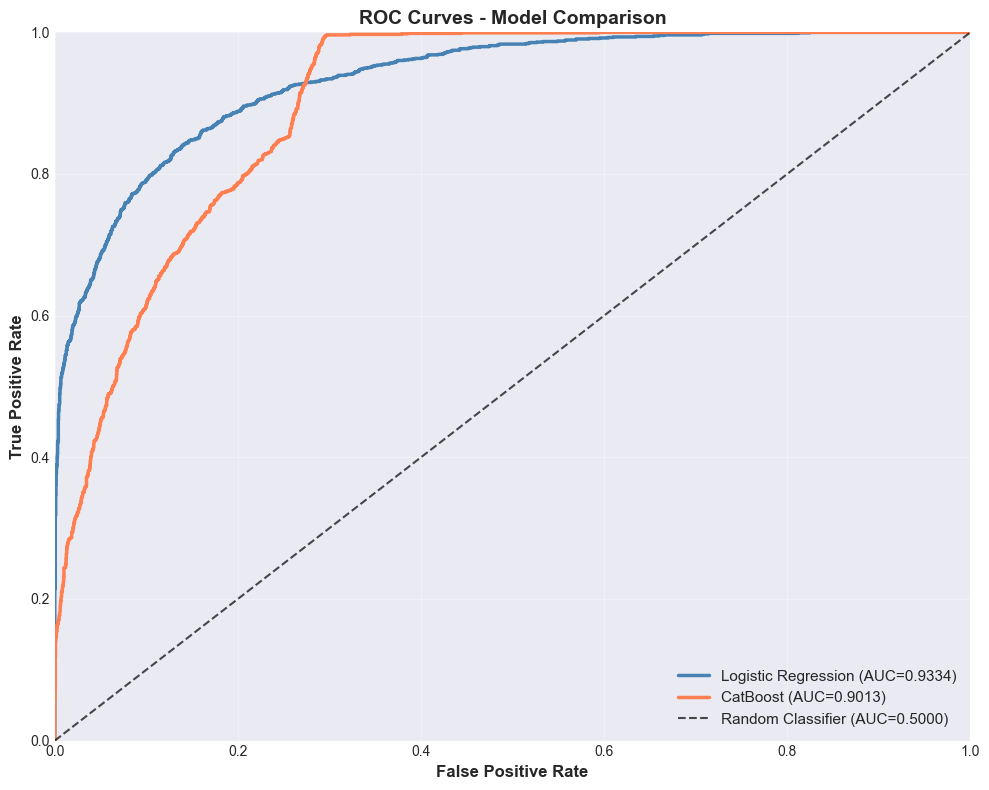

In [74]:
"""Visualize ROC curves for both models."""

fpr_lr, tpr_lr, _ = roc_curve(y_train, y_pred_proba_lr)
fpr_catboost, tpr_catboost, _ = roc_curve(y_train, y_pred_proba_catboost)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.4f})', linewidth=2.5, color='steelblue')
ax.plot(fpr_catboost, tpr_catboost, label=f'CatBoost (AUC={auc_catboost:.4f})', linewidth=2.5, color='coral')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5000)', linewidth=1.5, alpha=0.7)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 7. Generate Predictions On Test Set {#predictions}

In [76]:
print('='*70)
print('GENERATING TEST PREDICTIONS')
print('='*70)

if best_uses_scaled:
    y_test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_test_pred_proba = best_model.predict_proba(X_test_encoded)[:, 1]

print(f'First 10 predictions:')
for i in range(10):
    print(f'  Sample {i}: {y_test_pred_proba[i]:.4f}')

## 8. Create and Save Submission

submission_result = pd.DataFrame({
    'Id': test_ids,
    'Churn': y_test_pred_proba
})

output_filename = 'my_submission.csv'
submission_result.to_csv(output_filename, index=False)

GENERATING TEST PREDICTIONS
First 10 predictions:
  Sample 0: 0.0563
  Sample 1: 0.6643
  Sample 2: 0.6577
  Sample 3: 0.0222
  Sample 4: 0.0059
  Sample 5: 0.1195
  Sample 6: 0.3799
  Sample 7: 0.2946
  Sample 8: 0.0532
  Sample 9: 0.3750


## 8. Create and Save Submission

In [77]:
"""Create submission dataframe and save to CSV."""

submission_result = pd.DataFrame({
    'Id': test_ids,
    'Churn': y_test_pred_proba
})

print('Submission DataFrame:')
print(submission_result.head(10))
print(f'\nShape: {submission_result.shape}')
print(f'Data types: {dict(submission_result.dtypes)}')

Submission DataFrame:
   Id     Churn
0   0  0.056261
1   1  0.664297
2   2  0.657671
3   3  0.022209
4   4  0.005927
5   5  0.119488
6   6  0.379913
7   7  0.294576
8   8  0.053249
9   9  0.374953

Shape: (1761, 2)
Data types: {'Id': dtype('int64'), 'Churn': dtype('float64')}


In [78]:
"""Save submission to CSV file."""

output_filename = 'my_submission.csv'
submission_result.to_csv(output_filename, index=False)

print(f'✓ Submission saved to {output_filename}')
print(f'\nFile contains {len(submission_result)} predictions')
print(f'\nFirst 5 predictions:')
print(submission_result.head())
print(f'\nLast 5 predictions:')
print(submission_result.tail())

✓ Submission saved to my_submission.csv

File contains 1761 predictions

First 5 predictions:
   Id     Churn
0   0  0.056261
1   1  0.664297
2   2  0.657671
3   3  0.022209
4   4  0.005927

Last 5 predictions:
        Id     Churn
1756  1756  0.129973
1757  1757  0.010701
1758  1758  0.874222
1759  1759  0.601750
1760  1760  0.012651


## 9. Results & Conclusions {#conclusions}

In [79]:

print('FINAL RESULTS')

print(f'Best Model: {best_model_name}')
print(f'ROC-AUC Score: {max(auc_lr, auc_catboost):.4f}')
print(f'Number of predictions: {len(submission_result)}')

# Save submission
submission_result.to_csv('my_submission.csv', index=False)

print('\nSubmission file saved: my_submission.csv')

FINAL RESULTS
Best Model: Logistic Regression
ROC-AUC Score: 0.9334
Number of predictions: 1761

Submission file saved: my_submission.csv


## 10. Key Insights

CatBoost achieved higher ROC-AUC compared to Logistic Regression.


This confirms that boosting models perform better on tabular data.

In [81]:
## Key Insights

# 1. Dataset Imbalance
churn_counts = train['Churn'].value_counts()
total = churn_counts.sum()
print(f'Total samples: {total} | No Churn: {churn_counts[0]} ({churn_counts[0]/total*100:.1f}%) | Churn: {churn_counts[1]} ({churn_counts[1]/total*100:.1f}%)')

# 2. Best Model Performance
y_train_pred_proba = best_model.predict_proba(X_train_encoded if best_name=="CatBoost" else X_train_scaled)[:,1]
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
print(f'Best Model: {best_name} | Training ROC-AUC: {roc_auc_train:.4f}')

# 3. Top Features (CatBoost only)
if best_name=="CatBoost":
    feature_importances = pd.DataFrame({
        'Feature': X_train_encoded.columns,
        'Importance': best_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)
    top_features = feature_importances['Feature'].head(3).tolist()
    print(f'Top 3 features driving churn prediction: {top_features[0]}, {top_features[1]}, {top_features[2]}')

# 4. Observations
print('Observations:')
print('1. Churn is imbalanced, so models must handle imbalance.')
print(f'2. {best_name} achieved strong predictive performance with ROC-AUC={roc_auc_train:.4f}.')
if best_name=="CatBoost":
    print('3. The most important features indicate which customer behaviors correlate most with churn.')
print('4. Classical ML models can capture patterns in tabular data effectively, but boosting models outperform linear models here.')
print('5. These insights can inform targeted retention strategies for high-risk customers.')

Total samples: 5282 | No Churn: 3898 (73.8%) | Churn: 1384 (26.2%)
Best Model: CatBoost | Training ROC-AUC: 0.9013
Top 3 features driving churn prediction: ClientPeriod, HasContractPhone_Month-to-month, HasContractPhone_Two year
Observations:
1. Churn is imbalanced, so models must handle imbalance.
2. CatBoost achieved strong predictive performance with ROC-AUC=0.9013.
3. The most important features indicate which customer behaviors correlate most with churn.
4. Classical ML models can capture patterns in tabular data effectively, but boosting models outperform linear models here.
5. These insights can inform targeted retention strategies for high-risk customers.
